In [5]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "cm",
#     "font.size": 10,
#     'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents} \usepackage{mathrsfs} \usepackage{bm}',
#     'figure.dpi': 200
# })

In [7]:
def get_last_file(path : Path) -> Path | None:
    pattern = os.path.join(path, "TR_IRGNM_*.pkl")
    files = glob.glob(pattern)
    
    indices = []
    for f in files:
        match = re.search(r'TR_IRGNM_(\d+)\.pkl$', f)
        if match:
            idx = int(match.group(1))
            indices.append((idx, f))
    
    if indices:
        _, max_file = max(indices, key=lambda x: x[0])
        
        return Path(max_file).name
    else:
        print("No matching files found.")

    return None

In [51]:
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
WORK_DIR = Path('/home/dealii/workdir/experiments')

#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/parabolische_inverse_probleme/figures/experiments')

data_dir_path = WORK_DIR / 'everywhere'

FOM_data_path = data_dir_path / 'FOM_high_res_sensors'


pattern = re.compile(r'^TR_.*_res_sensors.*')

experiment_names = [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

TR_data_paths = [ data_dir_path / experiment_name for experiment_name in experiment_names]
TR_file_names = [get_last_file(TR_data_path) for TR_data_path in TR_data_paths]

assert len(TR_data_paths) == len(TR_file_names)


setup_path = FOM_data_path / 'setup.pkl'
optimizer_parameter_path = FOM_data_path / 'optimizer_parameter.pkl'


with open(setup_path, 'rb') as file:
    setup = load(file)

with open(optimizer_parameter_path, 'rb') as file:
    optimizer_parameter = load(file)

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

    

data = {}
optimizer_parameters = {}
FOM_key = None

if TR_data_paths:
    for (TR_data_path, TR_file_name) in zip(TR_data_paths, TR_file_names):            

        try:
            with open(TR_data_path / TR_file_name, 'rb') as file:
                TR_data = load(file)
            data[str(TR_data_path.name)] = TR_data
        except TypeError:
            print(f"Can not find dumps for {TR_data_path}")
        except:
            print(f"Can not open {TR_data_path / TR_file_name}")
            

        optimizer_parameter_path = TR_data_path / 'optimizer_parameter.pkl'
        with open(optimizer_parameter_path, 'rb') as file:
            optimizer_parameter = load(file)
            
        optimizer_parameters[str(TR_data_path.name)] = optimizer_parameter
        
if FOM_data_path:
    with open(FOM_data_path / 'FOM_IRGNM_11.pkl', 'rb') as file:
        FOM_data = load(file)
    data[str(FOM_data_path.name)] = FOM_data      
    
    optimizer_parameter_path = TR_data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
            
    optimizer_parameters[str(FOM_data_path.name)] = optimizer_parameter
    FOM_key = str(FOM_data_path.name)


No matching files found.
No matching files found.
Can not find dumps for /home/dealii/workdir/experiments/everywhere/TR_high_res_sensors_include_each_time_step
Can not find dumps for /home/dealii/workdir/experiments/everywhere/TR_low_res_sensors_include_each_time_step


In [37]:
# for key, d in data['TR_30_5_10-5_legacy']['outer_loop_runtime'].items():    
#     if isinstance(d, dict):
#         for key_, d_ in d.items():
#             idxes = np.arange(len(d_))
#             plt.plot(idxes,np.array(d_), label=key_)
#     else:
#         idxes = np.arange(len(d),dtype=np.float32)
#         idxes += 0.5
#         plt.plot(np.array(d), label=key)

# #plt.yscale('log')
# plt.ylim([1e-3, 16*1e3])
# plt.grid()
# plt.legend()



In [38]:
# for key, d in data['TR_30_5_10-5']['outer_loop_runtime'].items():    
#     if isinstance(d, dict):
#         for key_, d_ in d.items():
#             idxes = np.arange(len(d_))
#             plt.plot(idxes,np.array(d_), label=key_)
#     else:
#         idxes = np.arange(len(d),dtype=np.float32)
#         idxes += 0.5
#         plt.plot(np.array(d), label=key)

# #plt.yscale('log')
# plt.ylim([1e-3, 16*1e3])
# plt.grid()
# plt.legend()


In [52]:
#plt.plot(data['FOM']['J'], marker='o', label='FOM')

TR_Js = []
inner_loop_statistics = data['TR']['inner_loop_statistics']
idxes = []

for inner_loop_statistic in inner_loop_statistics:
    TR_Js += inner_loop_statistic['J']
    idxes.append(len(inner_loop_statistic['J']))
    plt.axvline(len(TR_Js), color='r')

plt.plot(TR_Js, marker='o', label='TR')
plt.yscale('log')
plt.legend()
plt.grid()

KeyError: 'TR'

In [53]:
data['FOM']['optimizer_parameter']['tau']

1.0

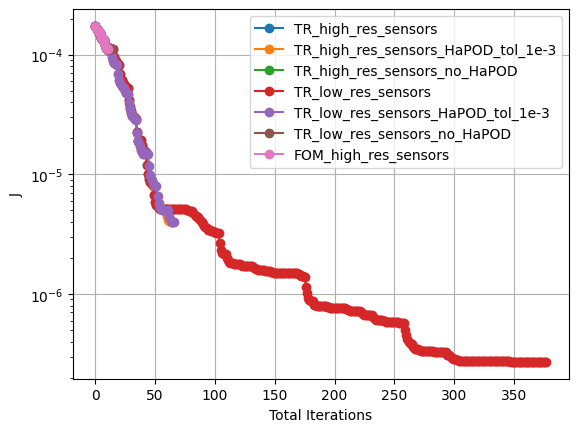

In [52]:
#for experiment_name, experiment_data in data.items():
for experiment_name, experiment_data in dict(list(data.items())[:]).items():
    Js = []
    idxes = []
    try:
        inner_loop_statistics = experiment_data['inner_loop_statistics']
        for inner_loop_statistic in inner_loop_statistics:
            Js += inner_loop_statistic['J']
            # idxes.append(len(inner_loop_statistic['J']))
            # plt.axvline(len(TR_Js), color='r')
    except:
        Js += experiment_data['J']

        
    plt.plot(Js, marker='o', label=experiment_name)


tau = optimizer_parameters[FOM_key]['tau']
delta = setup['noise_level']

#plt.axhline(0.5 * tau**2 * delta**2, color='black')

plt.ylabel('J')
plt.xlabel('Total Iterations')
plt.yscale('log')
plt.legend()
plt.grid()
    

In [44]:
len(data[FOM_key]['total_runtime'])

30

In [41]:
data[FOM_key]['J']

[0.015562747154835598,
 0.012610777610557648,
 0.010000257394943158,
 0.007900636597796292,
 0.006355979160200972,
 0.005245864153306624,
 0.004445892467859427,
 0.003860820779608397,
 0.00342287625306497,
 0.003088795171026201,
 0.0028296017374229107,
 0.002625234244884338,
 0.0024616853590739714,
 0.0023289880534622894,
 0.0022199462564545997,
 0.002129308477163622,
 0.0020531457989370456,
 0.0019885130179340166,
 0.001933145113170106,
 0.0018853004961399509,
 0.001843609014007216,
 0.0018070052377303194,
 0.0017746361874176409,
 0.0017458025046334308,
 0.0017199595352395396,
 0.0016966544213180839,
 0.0016755174963938404,
 0.0016562378108207752,
 0.001458246280668287,
 0.0013424136140330902,
 0.0012637874756755384,
 0.0012058901128143781]

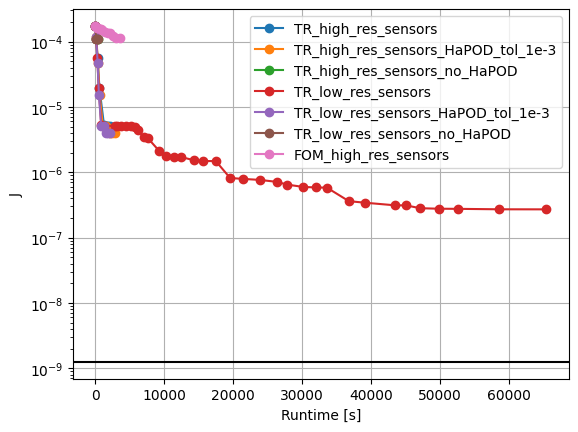

In [53]:
for experiment_name, experiment_data in dict(list(data.items())[:]).items():
    Js = experiment_data['J']
    times = np.array([0])
    times = np.append(times, experiment_data['total_runtime'])
    try:    
        plt.plot(times, Js, marker='o', label=experiment_name)
    except:
        #pass
        plt.plot(times, Js[:-1], marker='o', label=experiment_name)


_, FOM_data_ = list(optimizer_parameters.items())[-1]
tau = FOM_data_['tau']
delta = setup['noise_level']

plt.axhline(0.5 * tau**2 * delta**2, color='black')

plt.ylabel('J')
plt.xlabel('Runtime [s]')
plt.yscale('log')
plt.legend()
plt.grid()

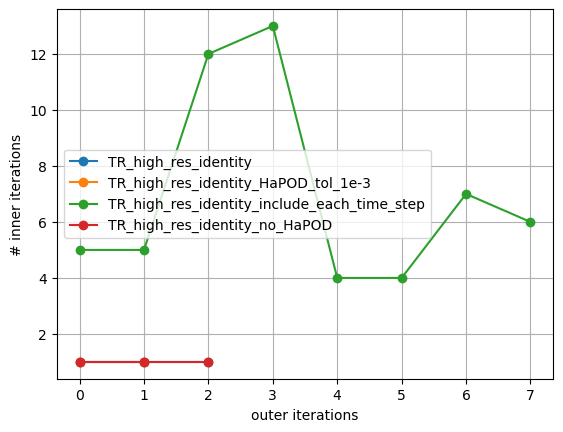

In [33]:
for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    num_inner_iterations = []
    inner_loop_statistics = experiment_data['inner_loop_statistics']
    for inner_loop_statistic in inner_loop_statistics:
        num_inner_iterations.append(len(inner_loop_statistic['J']))

    plt.plot(num_inner_iterations, marker='o', label=experiment_name)
        

plt.ylabel('# inner iterations')
plt.xlabel('outer iterations')
plt.legend()
plt.grid()
            

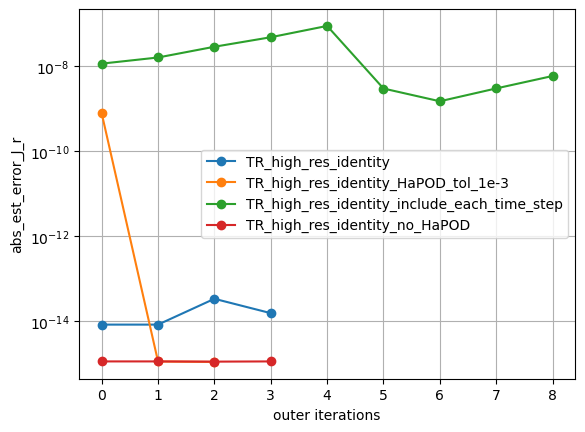

In [34]:
for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    plt.plot(experiment_data['abs_est_error_J_r'], marker='o', label=experiment_name)
    #plt.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        

#plt.ylabel('# inner iterations')


plt.ylabel('abs_est_error_J_r')
plt.xlabel('outer iterations')
plt.yscale('log')
plt.legend()
plt.grid()

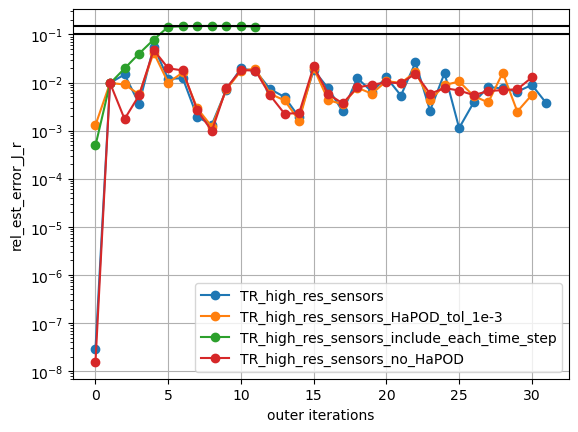

In [51]:
for experiment_name, experiment_data in dict(list(data.items())[:-1]).items():
    plt.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        




plt.axhline(0.10, color='black')
plt.axhline(0.15, color='black')

# beta_2 = optimizer_parameters['TR_30_5_10-5']['beta_2']
# plt.axhline(beta_2 * 0.10, color='black')
# plt.axhline(beta_2 *0.15, color='black')

plt.ylabel('rel_est_error_J_r')
plt.xlabel('outer iterations')
plt.yscale('log')
plt.legend()
plt.grid()
            

In [8]:
data['TR']['dim_Q_r']

[19, 37, 55, 74, 81, 81]

In [314]:
data['TR']['dim_V_r']

[78, 157, 200, 200, 200, 200, 200, 200, 200]

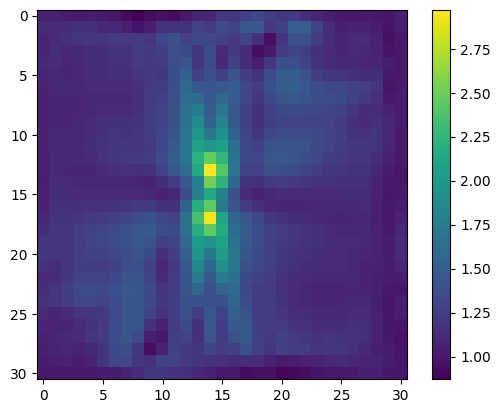

In [54]:
plt.imshow(data[FOM_key]['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

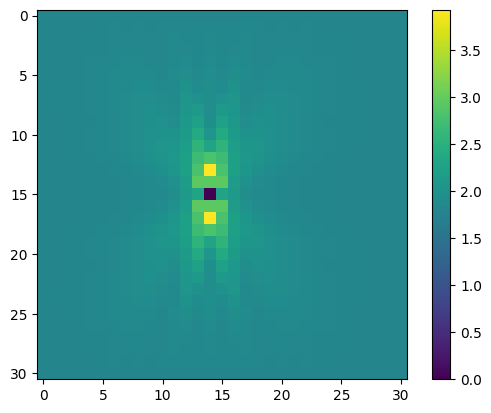

In [29]:
plt.imshow(data['TR_low_res_identity']['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

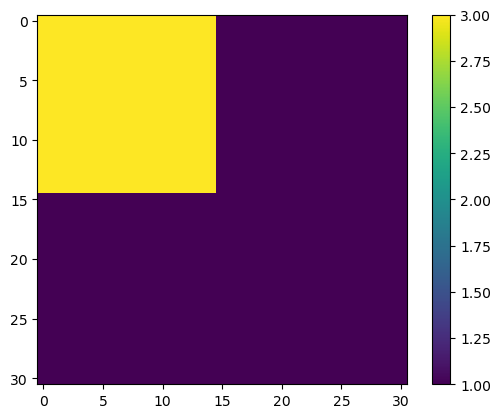

In [36]:
plt.imshow(setup['q_exact'].reshape((31,31)))
#plt.imshow(setup['q_exact'].reshape((9,9)))

plt.colorbar() 